# Intrusion Detection System — Feature Selection / Dimensionality Reduction
### Dataset: CICIDS-2017  ·  Runs on **Kaggle**

Runs *after* `FeatureEngineering.ipynb`. Takes the engineered, scaled `train_engineered.parquet`
and decides **which features to keep** for modelling.

**Method — correlation-based feature selection:**
| # | Step | What it does |
|---|------|--------------|
| 1 | Target correlation | For every feature, measure its relationship to **both** targets (binary + multi-class) using **Pearson**, **Spearman**, and **Mutual Information** |
| 2 | Inter-feature correlation | Build the feature-vs-feature correlation matrix; find pairs with \|r\| > threshold |
| 3 | Redundancy resolution | For each redundant pair, **drop the feature with the weaker target correlation**, keep the stronger one |
| 4 | SMOTE | Build class-balanced training sets **on the selected features** — one for the binary task, one for the multi-class task |
| 5 | Save | reduced feature list + reduced train/test parquet + both SMOTE train sets + report/figures |

**Strategy : redundancy-only.** We only drop features that are *redundant* (highly correlated with a kept feature that carries stronger target signal). Features with modest-but-unique signal are kept — a feature can matter in interaction even if its solo correlation is low.

**Note:** `Preprocessing.ipynb` already removed pairs at \|r\| > 0.95. This second pass at the same threshold mostly *confirms* that and adds the rigorous target-correlation analysis. If it drops nothing, that is an expected, valid result — lower `CORR_THRESHOLD` if you want a more aggressive cut.

**Why SMOTE is built here (not in Feature Engineering):** SMOTE interpolates between samples, so it belongs in the *final* feature space — after redundant columns are removed. Building it here also keeps it column-consistent with `train_selected.parquet` (all 47 features), so the modelling notebooks need only this one dataset. Both the binary and multi-class SMOTE sets are produced in a single run, so FeatureSelection never needs re-running.

**Kaggle setup:**
1. The output of `FeatureEngineering.ipynb` (`train_engineered.parquet`, `test_engineered.parquet`, `feature_list.json`) must be uploaded as a Kaggle **Dataset**.
2. New Kaggle Notebook → *Add Input* → attach that dataset.
3. **Settings → Internet: ON** (needed for `pip install imbalanced-learn`).
4. Set `IN_DIR` below to wherever Kaggle mounted that dataset.

**Outputs (to `/kaggle/working/`):**
- `train_selected.parquet` / `test_selected.parquet` — reduced feature set (47 features)
- `train_binary_smote_selected.parquet` — SMOTE-balanced training set (47 features, binary target)
- `train_multi_smote_selected.parquet` — SMOTE-balanced training set (47 features, multi-class target, capped per class)
- `selected_features.json` — kept/dropped feature lists + the reason for each drop
- `target_correlation.csv` — full Pearson/Spearman/MI table vs both targets
- `FeatureSelection_Report.txt` + `figures/`

## 1. Imports, Config & Report Helpers

In [3]:
!pip install -q imbalanced-learn

import os, json, warnings
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr
from sklearn.feature_selection import mutual_info_classif
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.bbox'] = 'tight'

RANDOM_SEED    = 42
CORR_THRESHOLD = 0.95     # inter-feature |r| above this = redundant pair
MI_SAMPLE_N    = 150_000  # stratified sample size for the (slow) MI computation

# ── Kaggle paths ───────────────────────────────────────────────────
# IN_DIR : the Kaggle Dataset holding the FeatureEngineering.ipynb output
#          (train_engineered.parquet / test_engineered.parquet / feature_list.json).
#   ----> EDIT THIS to match where Kaggle mounted your dataset. Check the
#         'Input' panel on the right in the Kaggle notebook for the exact path.
IN_DIR      = '/kaggle/input/datasets/hanzlahmunir/fe-output'
OUT_DIR     = '/kaggle/working'
FIGURES_DIR = os.path.join(OUT_DIR, 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

# ── report helpers ─────────────────────────────────────────────────
_report_lines = []

def _log(text=''):
    _report_lines.append(str(text))
    print(text)

def _savefig(name, fig=None):
    path = os.path.join(FIGURES_DIR, name)
    (fig or plt).savefig(path, dpi=130, bbox_inches='tight')
    return path

def write_report():
    path = os.path.join(OUT_DIR, 'FeatureSelection_Report.txt')
    with open(path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(_report_lines))
    print(f'\nReport saved -> {path}')

_log('=' * 70)
_log('FEATURE SELECTION REPORT  —  CICIDS-2017')
_log(f'Generated : {datetime.now().strftime("%Y-%m-%d %H:%M")}')
_log(f'Strategy  : redundancy-only  |  inter-feature |r| threshold = {CORR_THRESHOLD}')
_log('=' * 70)
print('\nSetup complete.')
print('  Reading from :', IN_DIR)
print('  Writing to   :', OUT_DIR)

FEATURE SELECTION REPORT  —  CICIDS-2017
Generated : 2026-05-14 17:19
Strategy  : redundancy-only  |  inter-feature |r| threshold = 0.95

Setup complete.
  Reading from : /kaggle/input/datasets/hanzlahmunir/fe-output
  Writing to   : /kaggle/working


## 2. Load Engineered Data
Loads the scaled (non-SMOTE) training set — feature selection decisions are made on the **real-distribution training data**, never on SMOTE-synthesised rows.

In [4]:
train_path = os.path.join(IN_DIR, 'train_engineered.parquet')
test_path  = os.path.join(IN_DIR, 'test_engineered.parquet')
flist_path = os.path.join(IN_DIR, 'feature_list.json')

if not os.path.exists(train_path):
    raise FileNotFoundError(
        f'{train_path} not found. Set IN_DIR to the Kaggle mount path of your '
        'FeatureEngineering output dataset (see the Input panel on the right).')

train_df = pd.read_parquet(train_path)
test_df  = pd.read_parquet(test_path)

LABEL_COLS   = ['label_binary', 'label_multi']
feature_cols = [c for c in train_df.columns if c not in LABEL_COLS]

y_bin   = train_df['label_binary'].values
y_multi = train_df['label_multi'].values

_log('')
_log('── STEP 0 : LOADED ENGINEERED DATA ────────────────────────')
_log(f'  Train : {train_df.shape[0]:,} rows x {train_df.shape[1]} cols')
_log(f'  Test  : {test_df.shape[0]:,} rows x {test_df.shape[1]} cols')
_log(f'  Features going into selection : {len(feature_cols)}')
print('\nFeatures:')
print(feature_cols)


── STEP 0 : LOADED ENGINEERED DATA ────────────────────────
  Train : 2,059,411 rows x 60 cols
  Test  : 514,853 rows x 60 cols
  Features going into selection : 58

Features:
['Destination Port', 'Fwd Packet Length Min', 'Fwd Packet Length Std', 'Bwd Packet Length Min', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Down/Up Ratio', 'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Fwd Header Length.1', 'Subflow Fwd Bytes', 'Subflow Bwd Bytes', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'min_s

## 3. Target Correlation — Pearson, Spearman, Mutual Information
For every feature we measure how strongly it relates to **each target**:
- **Pearson**  — linear correlation with the target
- **Spearman** — rank (monotonic) correlation — catches non-linear-but-monotonic relationships
- **Mutual Information** — captures *any* statistical dependency (linear or not)

We do this against **both** the binary and multi-class targets, because a feature weak for one task can be important for the other. The final 'target strength' of a feature is the **max** of its (absolute) scores — a feature is valuable if it helps *either* task.

In [5]:
X = train_df[feature_cols]

# ── Pearson & Spearman vs both targets ──
pearson_bin   = X.apply(lambda col: np.corrcoef(col, y_bin)[0, 1]).abs()
pearson_multi = X.apply(lambda col: np.corrcoef(col, y_multi)[0, 1]).abs()

spearman_bin   = X.apply(lambda col: spearmanr(col, y_bin).correlation).abs()
spearman_multi = X.apply(lambda col: spearmanr(col, y_multi).correlation).abs()

# ── Mutual information vs both targets (on a stratified sample for speed) ──
samp_idx = (pd.Series(y_multi)
            .groupby(y_multi, group_keys=False)
            .apply(lambda s: s.sample(min(len(s),
                                          max(1, MI_SAMPLE_N * len(s) // len(y_multi))),
                                      random_state=RANDOM_SEED))
            .index)
X_samp       = X.loc[samp_idx]
y_bin_samp   = train_df.loc[samp_idx, 'label_binary'].values
y_multi_samp = train_df.loc[samp_idx, 'label_multi'].values

mi_bin   = pd.Series(mutual_info_classif(X_samp, y_bin_samp,   random_state=RANDOM_SEED),
                     index=feature_cols)
mi_multi = pd.Series(mutual_info_classif(X_samp, y_multi_samp, random_state=RANDOM_SEED),
                     index=feature_cols)

# ── assemble the table ──
tc = pd.DataFrame({
    'pearson_bin':   pearson_bin,   'pearson_multi':  pearson_multi,
    'spearman_bin':  spearman_bin,  'spearman_multi': spearman_multi,
    'mi_bin':        mi_bin,        'mi_multi':       mi_multi,
}).fillna(0)

# normalise MI to 0-1 so it is comparable to the correlation columns
for c in ['mi_bin', 'mi_multi']:
    mx = tc[c].max()
    tc[c + '_norm'] = tc[c] / mx if mx > 0 else 0.0

# a single 'target strength' score per feature = max signal across all methods/targets
tc['target_strength'] = tc[['pearson_bin', 'pearson_multi',
                            'spearman_bin', 'spearman_multi',
                            'mi_bin_norm', 'mi_multi_norm']].max(axis=1)
tc = tc.sort_values('target_strength', ascending=False)

_log('')
_log('── STEP 1 : TARGET CORRELATION ────────────────────────────')
_log(f'  MI computed on stratified sample of {len(X_samp):,} rows')
_log('  Feature target-strength ranking (max signal across all methods):')
_log(tc[['pearson_bin', 'pearson_multi', 'spearman_bin', 'spearman_multi',
         'mi_bin', 'mi_multi', 'target_strength']].to_string())
display(tc[['pearson_bin', 'pearson_multi', 'spearman_bin', 'spearman_multi',
            'mi_bin', 'mi_multi', 'target_strength']])


── STEP 1 : TARGET CORRELATION ────────────────────────────
  MI computed on stratified sample of 149,996 rows
  Feature target-strength ranking (max signal across all methods):
                         pearson_bin  pearson_multi  spearman_bin  spearman_multi  mi_bin  mi_multi  target_strength
Average Packet Size           0.1706         0.1224        0.1787          0.1581  0.3374    0.5258           1.0000
Packet Length Variance        0.2319         0.1915        0.2210          0.2062  0.3292    0.4989           0.9758
Packet Length Std             0.2379         0.1996        0.2210          0.2061  0.3287    0.4993           0.9742
bwd_header_ratio              0.0372         0.1050        0.1438          0.1134  0.3040    0.4687           0.9010
Subflow Bwd Bytes             0.1706         0.1379        0.1821          0.1672  0.2997    0.4615           0.8883
fwd_bwd_byte_ratio            0.2168         0.2101        0.3464          0.3462  0.2921    0.4280           0.8658
Av

,pearson_bin,pearson_multi,spearman_bin,spearman_multi,mi_bin,mi_multi,target_strength
Average Packet Size,0.1706,0.1224,0.1787,0.1581,0.3374,0.5258,1.0000
Packet Length Variance,0.2319,0.1915,0.2210,0.2062,0.3292,0.4989,0.9758
Packet Length Std,0.2379,0.1996,0.2210,0.2061,0.3287,0.4993,0.9742
bwd_header_ratio,0.0372,0.1050,0.1438,0.1134,0.3040,0.4687,0.9010
Subflow Bwd Bytes,0.1706,0.1379,0.1821,0.1672,0.2997,0.4615,0.8883
fwd_bwd_byte_ratio,0.2168,0.2101,0.3464,0.3462,0.2921,0.4280,0.8658
Avg Bwd Segment Size,0.1893,0.1595,0.2093,0.1954,0.2908,0.4550,0.8653
Subflow Fwd Bytes,0.0706,0.1022,0.0786,0.0840,0.2655,0.4399,0.8365
Init_Win_bytes_backward,0.1278,0.1060,0.1894,0.1905,0.2679,0.4391,0.8350
Init_Win_bytes_forward,0.1949,0.1944,0.2152,0.2183,0.2519,0.4096,0.7790


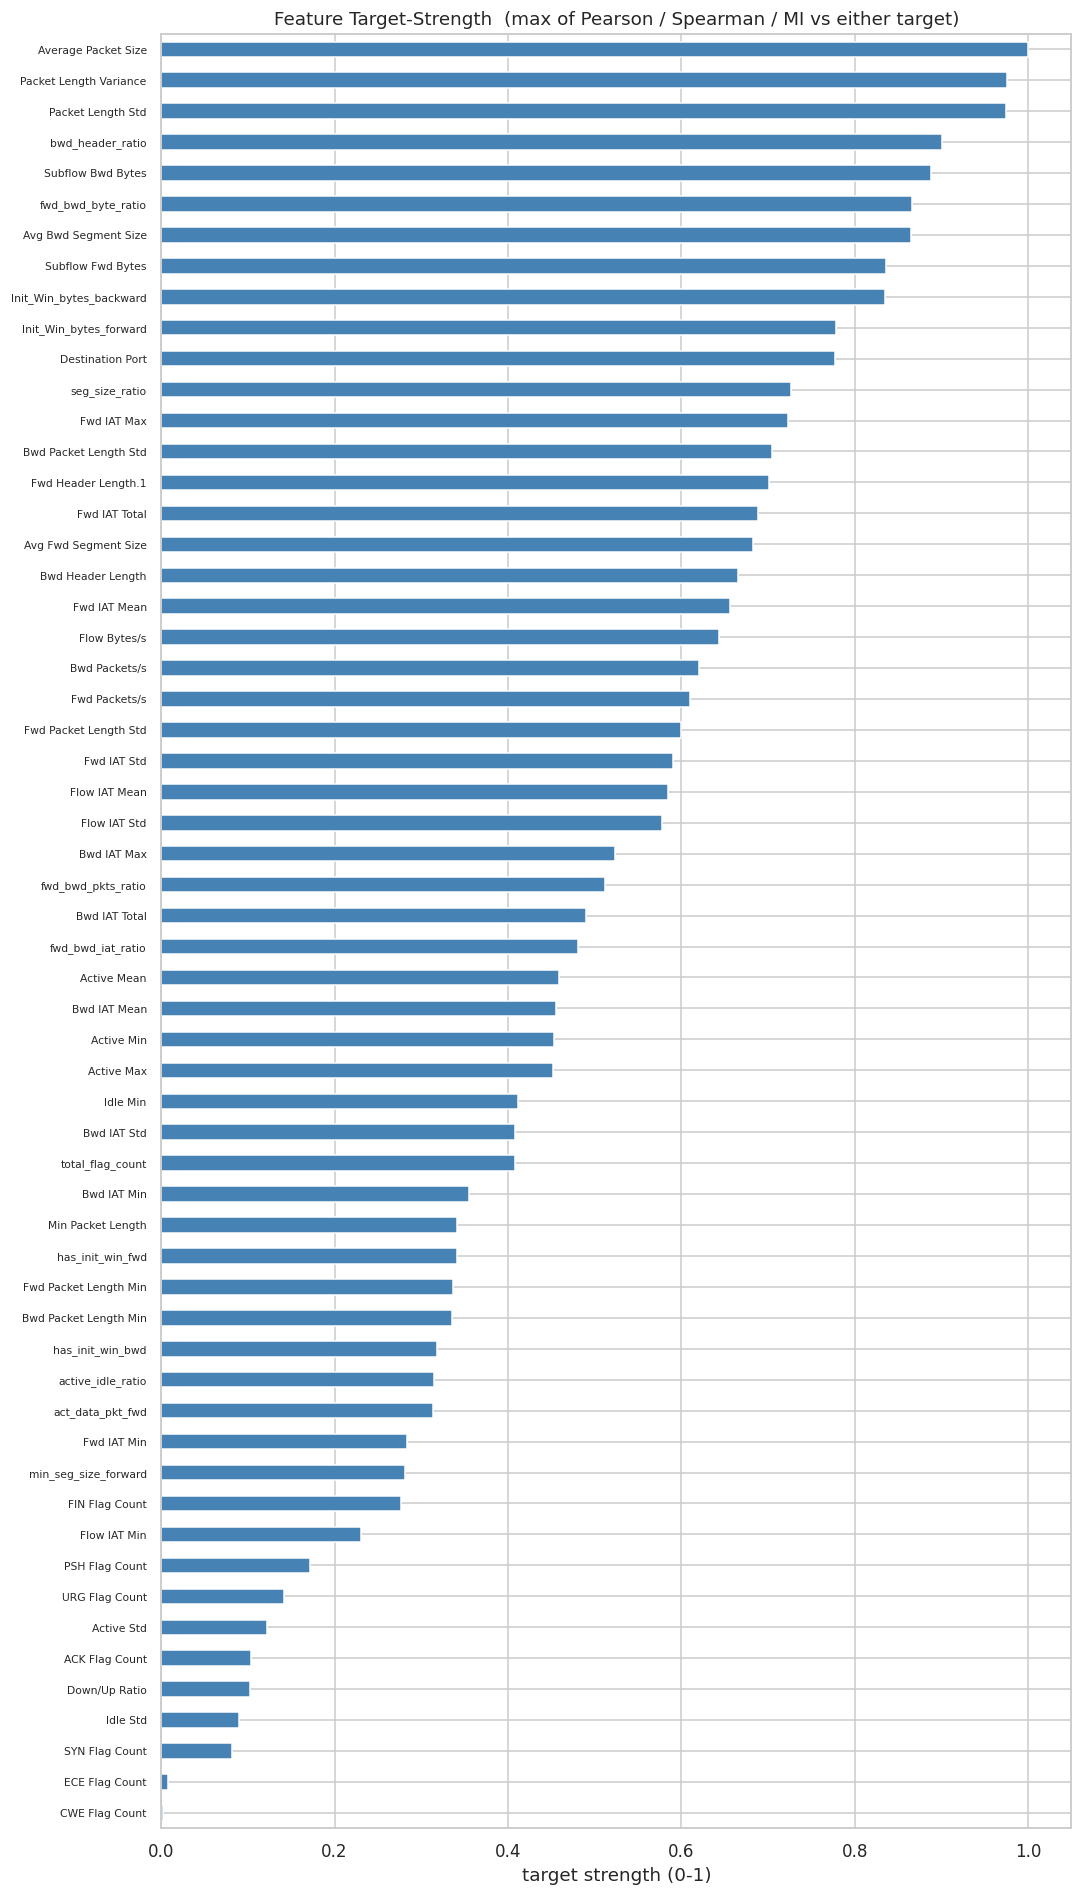

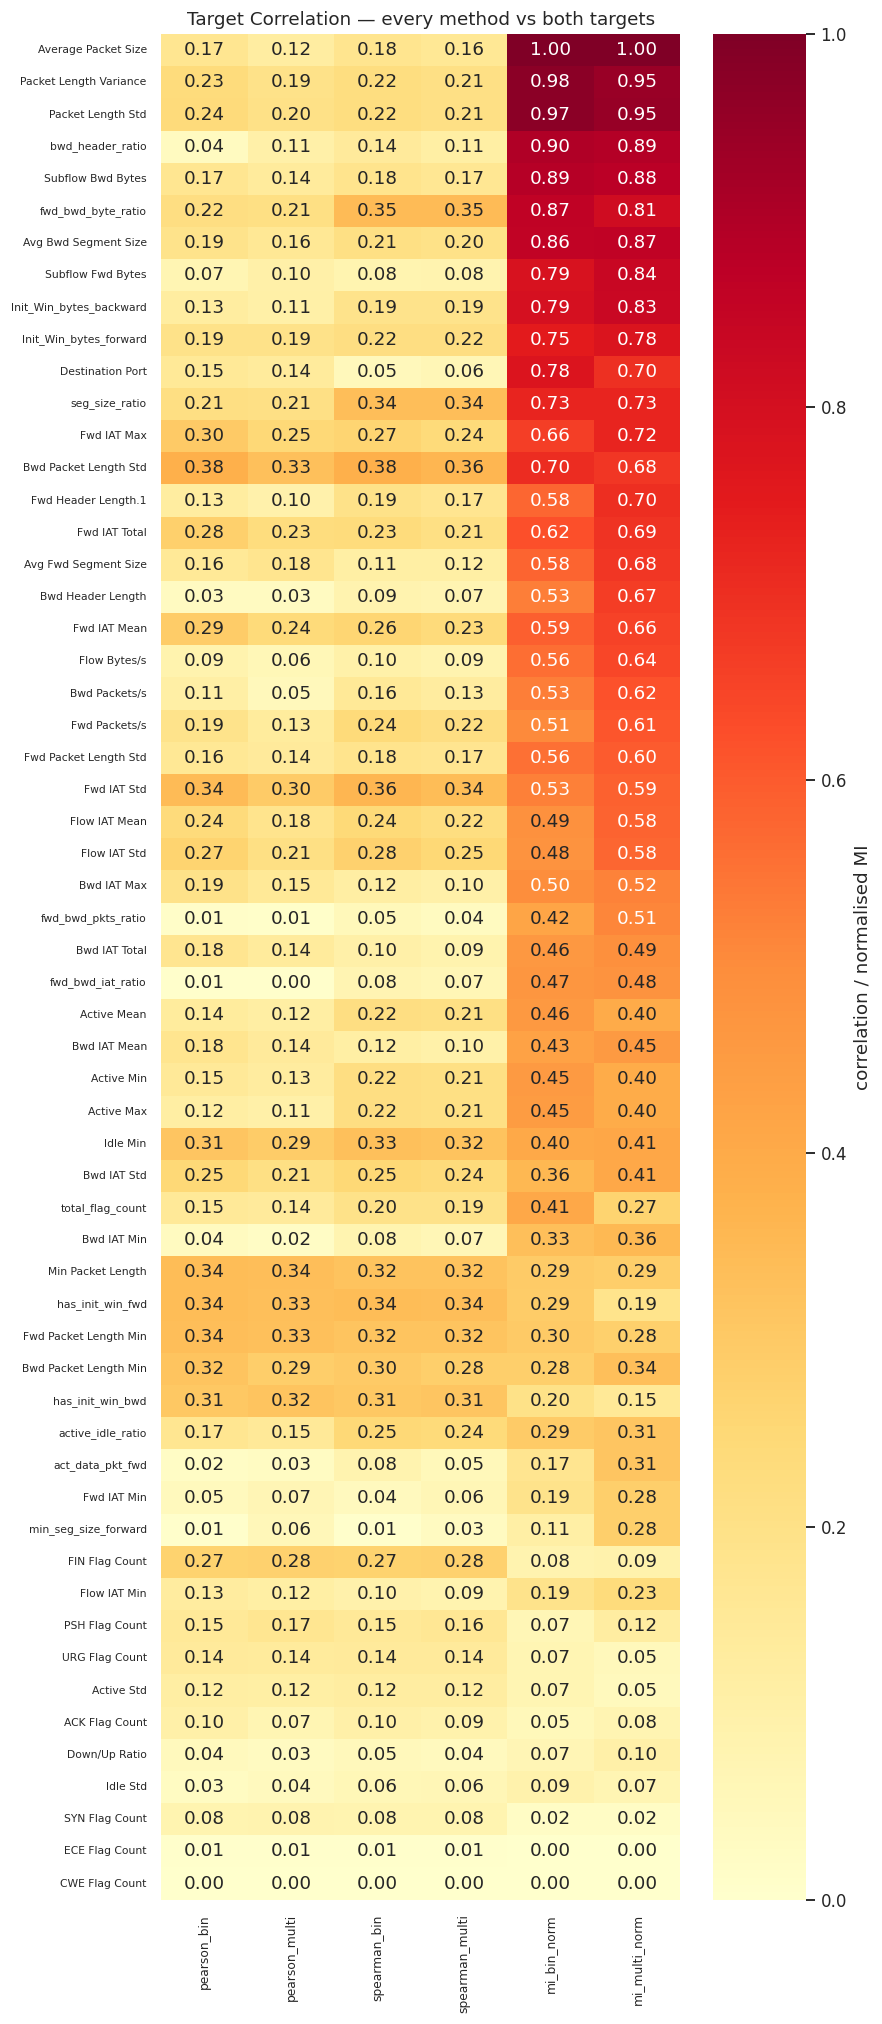

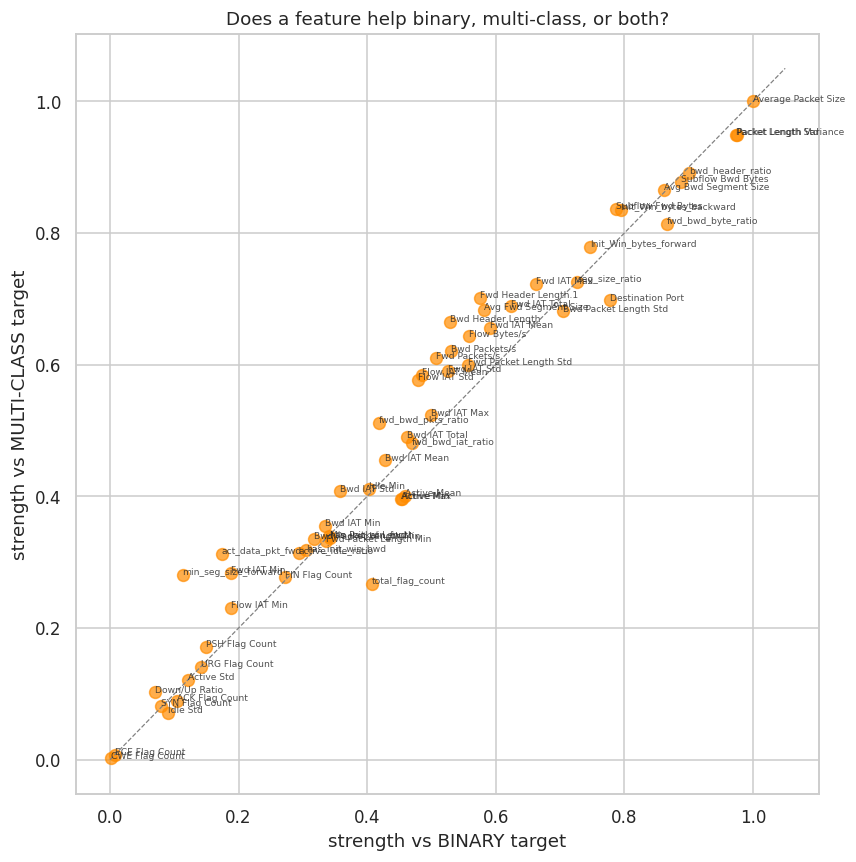

In [6]:
# ── plot 1: target-strength ranking bar ──
fig, ax = plt.subplots(figsize=(10, max(6, len(tc) * 0.3)))
tc['target_strength'].iloc[::-1].plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Target-Strength  (max of Pearson / Spearman / MI vs either target)')
ax.set_xlabel('target strength (0-1)')
ax.tick_params(axis='y', labelsize=7)
plt.tight_layout()
_savefig('01_target_strength.png', fig)
plt.show()

# ── plot 2: heatmap of all six methods per feature ──
methods = ['pearson_bin', 'pearson_multi', 'spearman_bin', 'spearman_multi',
           'mi_bin_norm', 'mi_multi_norm']
fig, ax = plt.subplots(figsize=(8, max(6, len(tc) * 0.32)))
sns.heatmap(tc[methods], annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=1,
            cbar_kws={'label': 'correlation / normalised MI'}, ax=ax,
            yticklabels=True)
ax.set_title('Target Correlation — every method vs both targets')
ax.tick_params(axis='y', labelsize=7)
ax.tick_params(axis='x', labelsize=8)
plt.tight_layout()
_savefig('02_target_corr_heatmap.png', fig)
plt.show()

# ── plot 3: binary vs multi-class target strength scatter ──
bin_strength   = tc[['pearson_bin', 'spearman_bin', 'mi_bin_norm']].max(axis=1)
multi_strength = tc[['pearson_multi', 'spearman_multi', 'mi_multi_norm']].max(axis=1)
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(bin_strength, multi_strength, s=60, alpha=0.7, color='darkorange')
for feat in tc.index:
    ax.annotate(feat, (bin_strength[feat], multi_strength[feat]), fontsize=6, alpha=0.8)
lim = max(bin_strength.max(), multi_strength.max()) * 1.05
ax.plot([0, lim], [0, lim], '--', color='gray', lw=0.8)
ax.set_xlabel('strength vs BINARY target')
ax.set_ylabel('strength vs MULTI-CLASS target')
ax.set_title('Does a feature help binary, multi-class, or both?')
plt.tight_layout()
_savefig('03_binary_vs_multi_strength.png', fig)
plt.show()

## 4. Inter-Feature Correlation
Now we look at correlation **between features** (not with the target). Two features with \|r\| above the threshold are *redundant* — they carry largely the same information, so keeping both adds noise and cost without adding signal.


── STEP 2 : INTER-FEATURE CORRELATION ─────────────────────
  Threshold              : |r| > 0.95
  Redundant pairs found  : 15
               feat_A                 feat_B  abs_r
    Packet Length Std Packet Length Variance 0.9997
          Active Mean             Active Max 0.9978
        Bwd IAT Total            Bwd IAT Max 0.9978
        Fwd IAT Total            Fwd IAT Max 0.9974
         Fwd IAT Mean            Fwd IAT Max 0.9969
         Bwd IAT Mean            Bwd IAT Max 0.9964
        Bwd IAT Total           Bwd IAT Mean 0.9952
        Fwd IAT Total           Fwd IAT Mean 0.9950
          Active Mean             Active Min 0.9917
           Active Max             Active Min 0.9855
Fwd Packet Length Min      Min Packet Length 0.9809
        Flow IAT Mean          Fwd Packets/s 0.9803
 Avg Bwd Segment Size      Subflow Bwd Bytes 0.9715
           Active Min      active_idle_ratio 0.9710
          Active Mean      active_idle_ratio 0.9610
Redundant pairs (|r| > 0.95): 15


,feat_A,feat_B,abs_r
1058,Packet Length Std,Packet Length Variance,0.9997
1549,Active Mean,Active Max,0.9978
709,Bwd IAT Total,Bwd IAT Max,0.9978
479,Fwd IAT Total,Fwd IAT Max,0.9974
526,Fwd IAT Mean,Fwd IAT Max,0.9969
751,Bwd IAT Mean,Bwd IAT Max,0.9964
707,Bwd IAT Total,Bwd IAT Mean,0.9952
477,Fwd IAT Total,Fwd IAT Mean,0.9950
1550,Active Mean,Active Min,0.9917
1575,Active Max,Active Min,0.9855


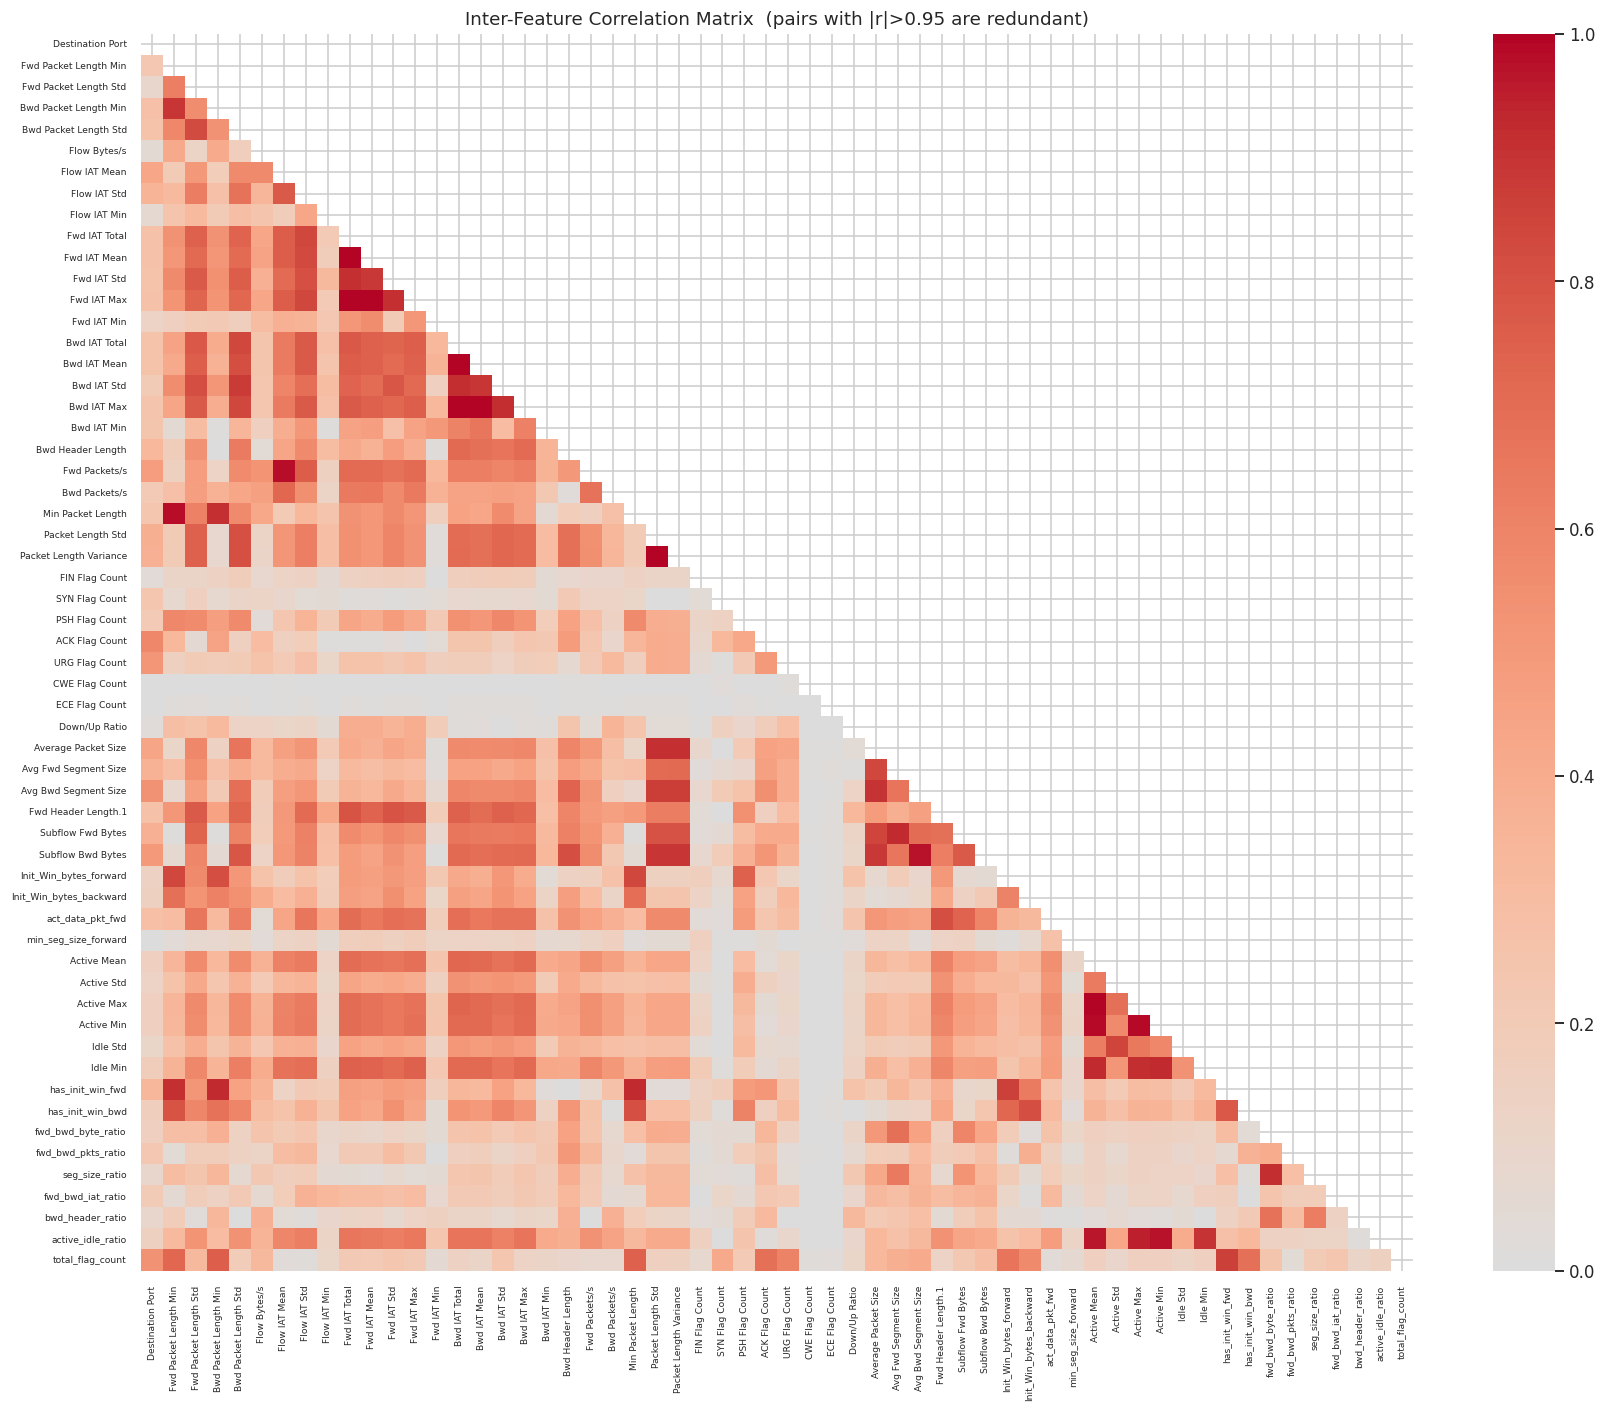

In [7]:
# Pearson correlation matrix between features
corr = train_df[feature_cols].corr().abs()

# upper triangle only (each pair once, no self-correlation)
upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))

pairs = (upper.stack()
              .reset_index()
              .rename(columns={'level_0': 'feat_A', 'level_1': 'feat_B', 0: 'abs_r'}))
redundant_pairs = pairs[pairs['abs_r'] > CORR_THRESHOLD].sort_values('abs_r', ascending=False)

_log('')
_log('── STEP 2 : INTER-FEATURE CORRELATION ─────────────────────')
_log(f'  Threshold              : |r| > {CORR_THRESHOLD}')
_log(f'  Redundant pairs found  : {len(redundant_pairs)}')
if len(redundant_pairs):
    _log(redundant_pairs.to_string(index=False))
else:
    _log('  No redundant pairs above threshold — preprocessing already removed them.')

print(f'Redundant pairs (|r| > {CORR_THRESHOLD}): {len(redundant_pairs)}')
display(redundant_pairs)

# heatmap of the full inter-feature correlation matrix
fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, vmin=0, vmax=1,
            square=False, ax=ax, xticklabels=True, yticklabels=True)
ax.set_title(f'Inter-Feature Correlation Matrix  (pairs with |r|>{CORR_THRESHOLD} are redundant)')
ax.tick_params(axis='x', rotation=90, labelsize=6)
ax.tick_params(axis='y', labelsize=6)
plt.tight_layout()
_savefig('04_inter_feature_corr.png', fig)
plt.show()

## 5. Redundancy Resolution — Drop the Weaker Feature
For each redundant pair, we keep the feature with the **stronger target correlation** and drop the other. This is the core of your method: *between two features that say the same thing, keep the one that better predicts the target.*

We process pairs from most-correlated downward, and skip a pair if one of its features was already dropped — so we never drop both members of a chain.


── STEP 3 : REDUNDANCY RESOLUTION ─────────────────────────
  Features before : 58
  Features dropped : 11
  Features kept    : 47
  Drop decisions (dropped <- kept, by target strength):
              dropped                   kept  abs_r  dropped_strength  kept_strength
    Packet Length Std Packet Length Variance 0.9997            0.9742         0.9758
           Active Max            Active Mean 0.9978            0.4524         0.4584
        Bwd IAT Total            Bwd IAT Max 0.9978            0.4897         0.5234
        Fwd IAT Total            Fwd IAT Max 0.9974            0.6888         0.7231
         Fwd IAT Mean            Fwd IAT Max 0.9969            0.6557         0.7231
         Bwd IAT Mean            Bwd IAT Max 0.9964            0.4548         0.5234
           Active Min            Active Mean 0.9917            0.4535         0.4584
Fwd Packet Length Min      Min Packet Length 0.9809            0.3365         0.3415
        Flow IAT Mean          Fwd Packets/s 0.

,dropped,kept,abs_r,dropped_strength,kept_strength
0,Packet Length Std,Packet Length Variance,0.9997,0.9742,0.9758
1,Active Max,Active Mean,0.9978,0.4524,0.4584
2,Bwd IAT Total,Bwd IAT Max,0.9978,0.4897,0.5234
3,Fwd IAT Total,Fwd IAT Max,0.9974,0.6888,0.7231
4,Fwd IAT Mean,Fwd IAT Max,0.9969,0.6557,0.7231
5,Bwd IAT Mean,Bwd IAT Max,0.9964,0.4548,0.5234
6,Active Min,Active Mean,0.9917,0.4535,0.4584
7,Fwd Packet Length Min,Min Packet Length,0.9809,0.3365,0.3415
8,Flow IAT Mean,Fwd Packets/s,0.9803,0.5847,0.6102
9,Avg Bwd Segment Size,Subflow Bwd Bytes,0.9715,0.8653,0.8883


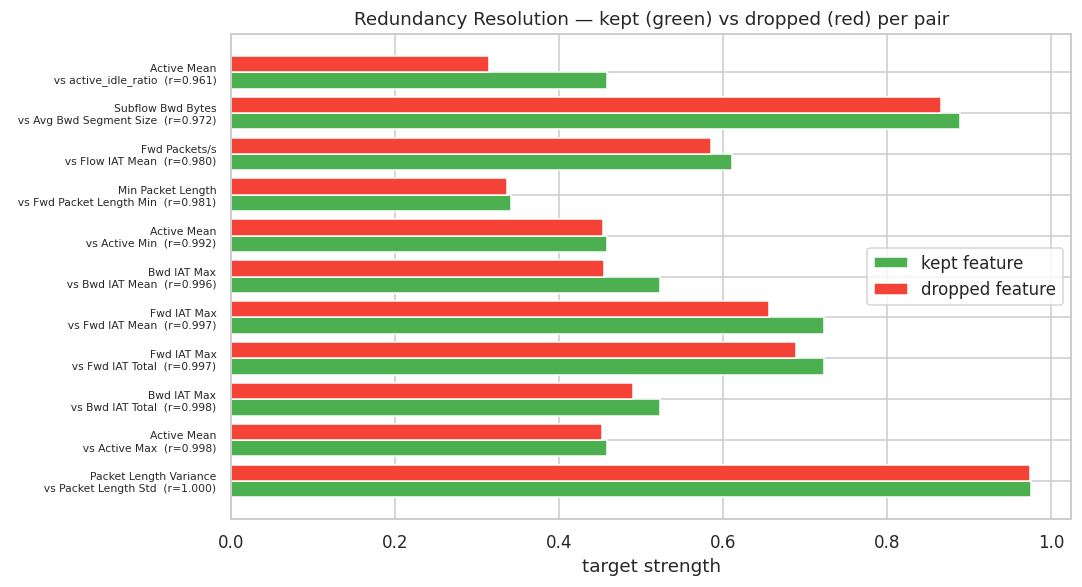

In [8]:
strength = tc['target_strength']        # one number per feature, computed in Step 1

to_drop   = set()
drop_log  = []   # (dropped, kept, abs_r, dropped_strength, kept_strength)

for _, row in redundant_pairs.iterrows():
    a, b, r = row['feat_A'], row['feat_B'], row['abs_r']
    if a in to_drop or b in to_drop:
        continue                         # this redundancy already resolved
    # keep the stronger-target-correlation feature, drop the weaker
    if strength[a] >= strength[b]:
        keep, drop = a, b
    else:
        keep, drop = b, a
    to_drop.add(drop)
    drop_log.append({
        'dropped': drop, 'kept': keep, 'abs_r': r,
        'dropped_strength': strength[drop], 'kept_strength': strength[keep],
    })

selected_features = [c for c in feature_cols if c not in to_drop]
drop_df = pd.DataFrame(drop_log)

_log('')
_log('── STEP 3 : REDUNDANCY RESOLUTION ─────────────────────────')
_log(f'  Features before : {len(feature_cols)}')
_log(f'  Features dropped : {len(to_drop)}')
_log(f'  Features kept    : {len(selected_features)}')
if len(drop_df):
    _log('  Drop decisions (dropped <- kept, by target strength):')
    _log(drop_df.to_string(index=False))
else:
    _log('  Nothing dropped — no redundant pairs at this threshold.')
    _log('  (Lower CORR_THRESHOLD in the config cell for a more aggressive cut.)')

print(f'Kept {len(selected_features)} / {len(feature_cols)} features '
      f'(dropped {len(to_drop)})')
if len(drop_df):
    display(drop_df)

# plot: dropped vs kept, with their target strengths
if len(drop_df):
    fig, ax = plt.subplots(figsize=(10, max(3, len(drop_df) * 0.5)))
    y = np.arange(len(drop_df))
    ax.barh(y - 0.2, drop_df['kept_strength'],    0.4, color='#4CAF50', label='kept feature')
    ax.barh(y + 0.2, drop_df['dropped_strength'], 0.4, color='#F44336', label='dropped feature')
    ax.set_yticks(y)
    ax.set_yticklabels([f"{r.kept}\n  vs {r.dropped}  (r={r.abs_r:.3f})"
                        for r in drop_df.itertuples()], fontsize=7)
    ax.set_xlabel('target strength')
    ax.set_title('Redundancy Resolution — kept (green) vs dropped (red) per pair')
    ax.legend()
    plt.tight_layout()
    _savefig('05_redundancy_resolution.png', fig)
    plt.show()
else:
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.text(0.5, 0.5, f'No redundant pairs at |r| > {CORR_THRESHOLD}\n'
                      'all features kept',
            ha='center', va='center', fontsize=13, color='green',
            transform=ax.transAxes)
    ax.set_axis_off()
    ax.set_title('Redundancy Resolution')
    _savefig('05_redundancy_resolution.png', fig)
    plt.show()

## 6. Final Selected Feature Set
Summary of what survived, ranked by target strength — this is the feature list modelling will use.


── STEP 4 : FINAL SELECTED FEATURES ───────────────────────
  47 features kept, ranked by target strength:
     1. Average Packet Size          strength=1.0000
     2. Packet Length Variance       strength=0.9758
     3. bwd_header_ratio             strength=0.9010
     4. Subflow Bwd Bytes            strength=0.8883
     5. fwd_bwd_byte_ratio           strength=0.8658
     6. Subflow Fwd Bytes            strength=0.8365
     7. Init_Win_bytes_backward      strength=0.8350
     8. Init_Win_bytes_forward       strength=0.7790
     9. Destination Port             strength=0.7773
    10. seg_size_ratio               strength=0.7265
    11. Fwd IAT Max                  strength=0.7231
    12. Bwd Packet Length Std        strength=0.7042
    13. Fwd Header Length.1          strength=0.7017
    14. Avg Fwd Segment Size         strength=0.6830
    15. Bwd Header Length            strength=0.6654
    16. Flow Bytes/s                 strength=0.6431
    17. Bwd Packets/s                strengt

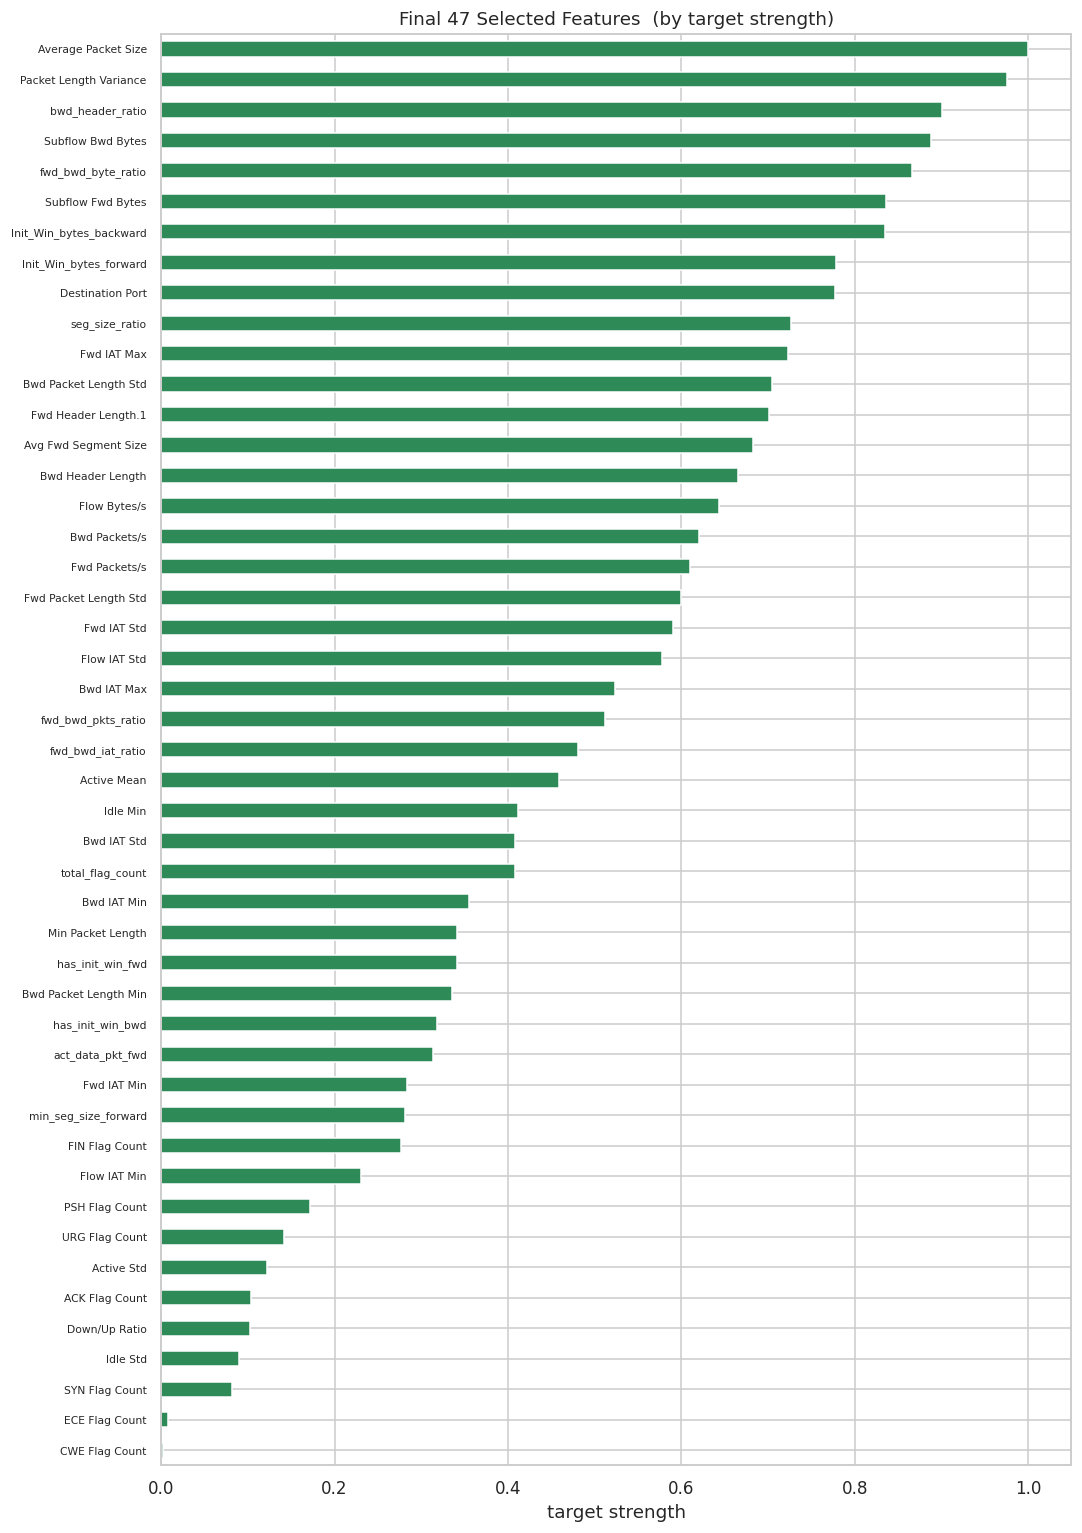

In [9]:
final_tc = tc.loc[selected_features].sort_values('target_strength', ascending=False)

_log('')
_log('── STEP 4 : FINAL SELECTED FEATURES ───────────────────────')
_log(f'  {len(selected_features)} features kept, ranked by target strength:')
for i, (feat, row) in enumerate(final_tc.iterrows(), 1):
    _log(f'    {i:2}. {feat:<28} strength={row["target_strength"]:.4f}')

fig, ax = plt.subplots(figsize=(10, max(6, len(final_tc) * 0.3)))
final_tc['target_strength'].iloc[::-1].plot(kind='barh', ax=ax, color='seagreen')
ax.set_title(f'Final {len(selected_features)} Selected Features  (by target strength)')
ax.set_xlabel('target strength')
ax.tick_params(axis='y', labelsize=7)
plt.tight_layout()
_savefig('06_final_features.png', fig)
plt.show()

## 6b. SMOTE-Balanced Training Set (on the selected features)
The training set is ~83% BENIGN. We produce a **SMOTE-balanced** version of the training data — built on the **final 47 selected features** so it is column-consistent with `train_selected.parquet`.

Why here and not in Feature Engineering: SMOTE interpolates between samples, so it should run in the *final* feature space — after redundant features are removed — otherwise synthetic points are placed using columns we later drop.

**Rules:** SMOTE is applied to the **training set only**; the test set keeps its real-world distribution. This file lets the modelling notebook compare *SMOTE* vs *class-weighting* head-to-head — the binary task uses `label_binary`.


── STEP 4b : SMOTE-BALANCED TRAINING SET ──────────────────
  Built on 47 selected features (binary target)
  Before : BENIGN=1,718,709  ATTACK=340,702
  After  : BENIGN=1,718,709  ATTACK=1,718,709
  Synthetic ATTACK rows added : 1,378,007
SMOTE: 2,059,411 -> 3,437,418 rows


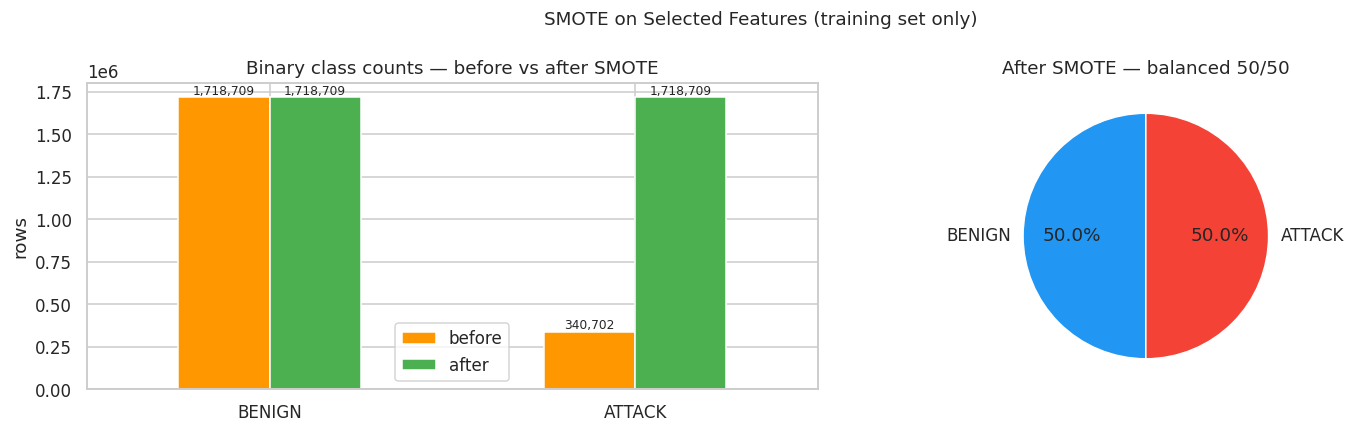

In [10]:
# SMOTE on the selected-feature training data (binary target)
X_train_sel = train_df[selected_features]
y_train_bin = train_df['label_binary']

bin_before = y_train_bin.value_counts().sort_index()

sm = SMOTE(random_state=RANDOM_SEED, k_neighbors=5)
X_smote, y_smote = sm.fit_resample(X_train_sel, y_train_bin)

bin_after = pd.Series(y_smote).value_counts().sort_index()

# assemble the balanced training frame (selected features + binary label)
train_smote_sel = X_smote.copy()
train_smote_sel['label_binary'] = y_smote.values

_log('')
_log('── STEP 4b : SMOTE-BALANCED TRAINING SET ──────────────────')
_log(f'  Built on {len(selected_features)} selected features (binary target)')
_log(f'  Before : BENIGN={bin_before.get(0,0):,}  ATTACK={bin_before.get(1,0):,}')
_log(f'  After  : BENIGN={bin_after.get(0,0):,}  ATTACK={bin_after.get(1,0):,}')
_log(f'  Synthetic ATTACK rows added : {bin_after.get(1,0) - bin_before.get(1,0):,}')

print(f'SMOTE: {len(train_df):,} -> {len(train_smote_sel):,} rows')

# before/after plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
b = pd.DataFrame({'before': bin_before, 'after': bin_after})
b.index = ['BENIGN', 'ATTACK']
b.plot(kind='bar', ax=axes[0], color=['#FF9800', '#4CAF50'])
axes[0].set_title('Binary class counts — before vs after SMOTE')
axes[0].set_ylabel('rows')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=8)
axes[1].pie([bin_after.get(0,0), bin_after.get(1,0)], labels=['BENIGN', 'ATTACK'],
            autopct='%1.1f%%', colors=['#2196F3', '#F44336'], startangle=90)
axes[1].set_title('After SMOTE — balanced 50/50')
plt.suptitle('SMOTE on Selected Features (training set only)', fontsize=12)
plt.tight_layout()
_savefig('07_smote_balance.png', fig)
plt.show()

## 6c. SMOTE-Balanced Training Set — Multi-class (7 attack families)
The same idea for the **multi-class** task (`label_multi`, 7 families). But multi-class needs one extra consideration:

**We cap each minority class instead of fully equalising.** Web Attack has only ~1,700 real rows — fully SMOTE-ing it up to the BENIGN count (~1.7M) would make it 99.9% synthetic, which produces meaningless interpolations. Instead each minority class is lifted up to `min(majority_count, MULTI_SMOTE_CAP)` — a sane synthetic-to-real ratio. The majority class (BENIGN) is left untouched.

Same rule as before: SMOTE on the **training set only**, built on the **47 selected features**, so it stays column-consistent with everything else.


── STEP 4c : SMOTE-BALANCED TRAINING SET (multi-class) ─────
  Built on 47 selected features (multi-class target)
  Per-minority-class target : min(majority, 200,000) = 200,000
  Class counts before -> after:
    class 0 :  1,718,709  ->   1,718,709
    class 1 :      1,591  ->     200,000
    class 2 :      7,322  ->     200,000
    class 3 :    102,413  ->     200,000
    class 4 :    155,007  ->     200,000
    class 5 :     72,655  ->     200,000
    class 6 :      1,714  ->     200,000
  Total rows : 2,059,411  ->  2,918,709
Multi-class SMOTE: 2,059,411 -> 2,918,709 rows


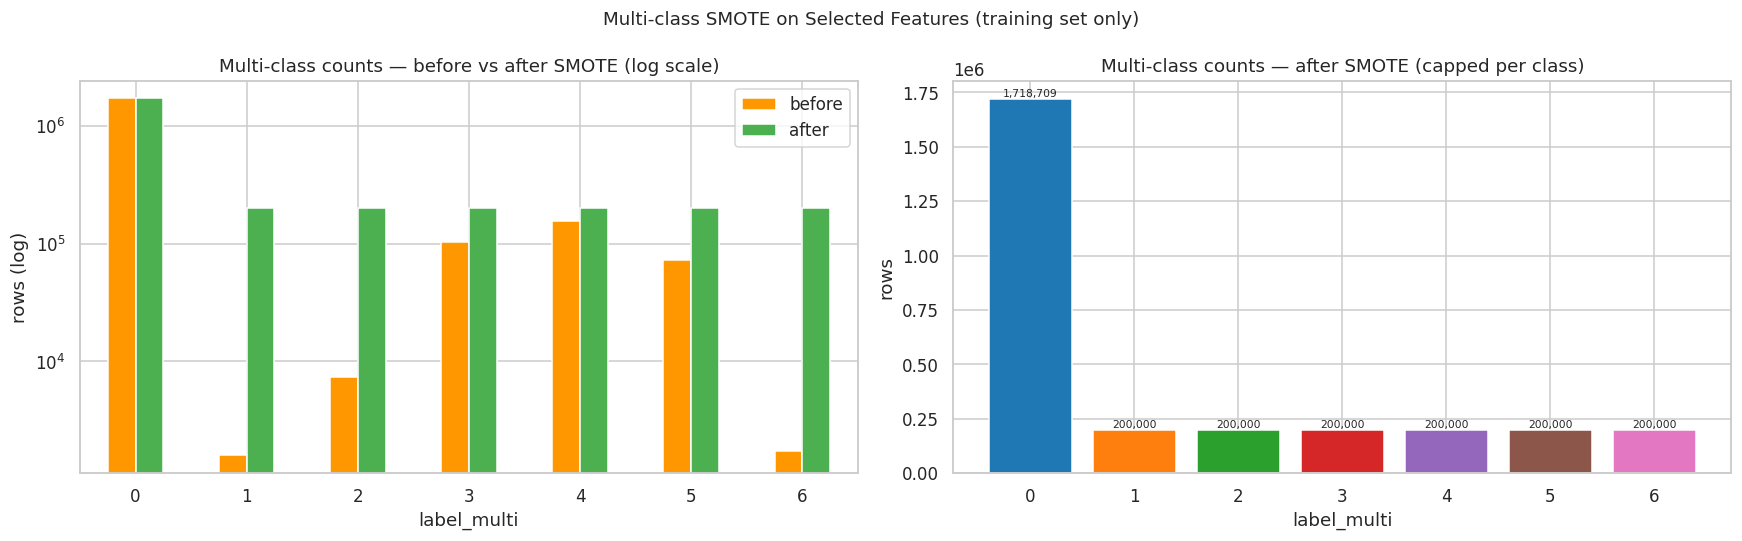

In [11]:
# SMOTE on the selected-feature training data (multi-class target)
MULTI_SMOTE_CAP = 200_000   # cap each minority class at this many rows

y_train_multi = train_df['label_multi']
multi_before  = y_train_multi.value_counts().sort_index()

# build a capped sampling strategy: lift each minority class up to
# min(majority_count, cap); leave the majority class alone
majority_cls = multi_before.idxmax()
majority_n   = multi_before.max()
target_n     = min(majority_n, MULTI_SMOTE_CAP)
sampling_strategy = {
    cls: max(int(n), int(target_n))
    for cls, n in multi_before.items()
    if cls != majority_cls
}

sm_multi = SMOTE(random_state=RANDOM_SEED, k_neighbors=5,
                 sampling_strategy=sampling_strategy)
X_multi_smote, y_multi_smote = sm_multi.fit_resample(X_train_sel, y_train_multi)

multi_after = pd.Series(y_multi_smote).value_counts().sort_index()

# assemble the balanced training frame (selected features + multi label)
train_multi_smote_sel = X_multi_smote.copy()
train_multi_smote_sel['label_multi'] = y_multi_smote.values

_log('')
_log('── STEP 4c : SMOTE-BALANCED TRAINING SET (multi-class) ─────')
_log(f'  Built on {len(selected_features)} selected features (multi-class target)')
_log(f'  Per-minority-class target : min(majority, {MULTI_SMOTE_CAP:,}) = {target_n:,}')
_log('  Class counts before -> after:')
for cls in multi_before.index:
    _log(f'    class {cls} : {multi_before[cls]:>10,}  ->  {multi_after.get(cls, 0):>10,}')
_log(f'  Total rows : {len(train_df):,}  ->  {len(train_multi_smote_sel):,}')

print(f'Multi-class SMOTE: {len(train_df):,} -> {len(train_multi_smote_sel):,} rows')

# before/after plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
m = pd.DataFrame({'before': multi_before, 'after': multi_after}).fillna(0)
m.plot(kind='bar', ax=axes[0], color=['#FF9800', '#4CAF50'], logy=True)
axes[0].set_title('Multi-class counts — before vs after SMOTE (log scale)')
axes[0].set_xlabel('label_multi')
axes[0].set_ylabel('rows (log)')
axes[0].tick_params(axis='x', rotation=0)

axes[1].bar(multi_after.index.astype(str), multi_after.values,
            color=sns.color_palette('tab10', len(multi_after)))
axes[1].set_title('Multi-class counts — after SMOTE (capped per class)')
axes[1].set_xlabel('label_multi')
axes[1].set_ylabel('rows')
for i, v in enumerate(multi_after.values):
    axes[1].text(i, v, f'{int(v):,}', ha='center', va='bottom', fontsize=7)

plt.suptitle('Multi-class SMOTE on Selected Features (training set only)', fontsize=12)
plt.tight_layout()
_savefig('08_smote_balance_multiclass.png', fig)
plt.show()

## 7. Save Reduced Datasets & Metadata

In [12]:
# reduced train/test — selected features + both label columns
train_sel = train_df[selected_features + LABEL_COLS].copy()
test_sel  = test_df[selected_features + LABEL_COLS].copy()

p1 = os.path.join(OUT_DIR, 'train_selected.parquet')
p2 = os.path.join(OUT_DIR, 'test_selected.parquet')
train_sel.to_parquet(p1, index=False)
test_sel.to_parquet(p2, index=False)

# SMOTE-balanced training sets (selected features) — one per task
p5 = os.path.join(OUT_DIR, 'train_binary_smote_selected.parquet')
p6 = os.path.join(OUT_DIR, 'train_multi_smote_selected.parquet')
train_smote_sel.to_parquet(p5, index=False)
train_multi_smote_sel.to_parquet(p6, index=False)

# selected feature metadata
p3 = os.path.join(OUT_DIR, 'selected_features.json')
with open(p3, 'w') as f:
    json.dump({
        'selected_features': selected_features,
        'dropped_features':  sorted(to_drop),
        'corr_threshold':    CORR_THRESHOLD,
        'strategy':          'redundancy-only',
        'drop_decisions':    drop_log,
    }, f, indent=2)

# full target correlation table
p4 = os.path.join(OUT_DIR, 'target_correlation.csv')
tc.to_csv(p4)

_log('')
_log('── STEP 5 : FILES SAVED ───────────────────────────────────')
for p in [p1, p2, p5, p6, p3, p4]:
    size = os.path.getsize(p) / 1e6
    _log(f'  {os.path.basename(p):40} {size:8.1f} MB')
    print(f'  {os.path.basename(p):40} {size:8.1f} MB')


── STEP 5 : FILES SAVED ───────────────────────────────────
  train_selected.parquet                      203.4 MB
  train_selected.parquet                      203.4 MB
  test_selected.parquet                        50.8 MB
  test_selected.parquet                        50.8 MB
  train_binary_smote_selected.parquet         393.6 MB
  train_binary_smote_selected.parquet         393.6 MB
  train_multi_smote_selected.parquet          293.5 MB
  train_multi_smote_selected.parquet          293.5 MB
  selected_features.json                        0.0 MB
  selected_features.json                        0.0 MB
  target_correlation.csv                        0.0 MB
  target_correlation.csv                        0.0 MB


## 8. Final Summary & Report

In [13]:
_log('')
_log('=' * 70)
_log('SUMMARY  —  FEATURE SELECTION')
_log('=' * 70)
_log(f'  Features in  : {len(feature_cols)}')
_log(f'  Features out : {len(selected_features)}   (dropped {len(to_drop)})')
_log(f'  Strategy     : redundancy-only @ |r| > {CORR_THRESHOLD}')
_log('')
_log('  Method:')
_log('    1. Target correlation: Pearson + Spearman + MI vs binary AND multi targets')
_log('    2. Inter-feature correlation matrix, pairs above threshold = redundant')
_log('    3. Per redundant pair: dropped the weaker-target-correlation feature')
_log('    4. Built SMOTE-balanced training sets (binary + multi-class) on selected features')
_log('')
if to_drop:
    _log(f'  Dropped: {sorted(to_drop)}')
else:
    _log('  Dropped: none (preprocessing already cleared |r|>0.95 redundancy).')
_log('')
_log('  Output files:')
_log('    train_selected.parquet / test_selected.parquet      (reduced feature set)')
_log('    train_binary_smote_selected.parquet                 (SMOTE-balanced, binary)')
_log('    train_multi_smote_selected.parquet                  (SMOTE-balanced, multi-class)')
_log('    selected_features.json   (kept/dropped lists + drop reasons)')
_log('    target_correlation.csv   (full Pearson/Spearman/MI table)')
_log('')
_log('  Next step -> Modelling:')
_log('    BINARY notebook  -> compares train_selected + class-weight  vs')
_log('                        train_binary_smote_selected (SMOTE)')
_log('    MULTI notebook   -> uses train_multi_smote_selected (SMOTE)')
_log('    Both evaluate on test_selected.parquet (real-world distribution).')

FIGURE_INDEX = [
    ('01_target_strength.png',           'Feature target-strength ranking'),
    ('02_target_corr_heatmap.png',       'All 6 corr/MI methods per feature'),
    ('03_binary_vs_multi_strength.png',  'Binary vs multi-class signal scatter'),
    ('04_inter_feature_corr.png',        'Inter-feature correlation matrix'),
    ('05_redundancy_resolution.png',     'Kept vs dropped per redundant pair'),
    ('06_final_features.png',            'Final selected features by strength'),
    ('07_smote_balance.png',             'SMOTE class balance before/after (binary)'),
    ('08_smote_balance_multiclass.png',  'SMOTE class balance before/after (multi-class)'),
]
_log('')
_log('  Figures:')
for fname, desc in FIGURE_INDEX:
    _log(f'    {fname:<36} {desc}')

write_report()

print('\n' + '=' * 55)
print('FEATURE SELECTION COMPLETE')
print('=' * 55)
print(f'  Features : {len(feature_cols)} -> {len(selected_features)}  (dropped {len(to_drop)})')
print(f'  Binary SMOTE train set : {len(train_smote_sel):,} rows ({len(selected_features)} features)')
print(f'  Multi  SMOTE train set : {len(train_multi_smote_sel):,} rows ({len(selected_features)} features)')
print(f'  Report   -> {OUT_DIR}/FeatureSelection_Report.txt')
print(f'  Figures  -> {FIGURES_DIR}/  ({len(FIGURE_INDEX)} figures)')


SUMMARY  —  FEATURE SELECTION
  Features in  : 58
  Features out : 47   (dropped 11)
  Strategy     : redundancy-only @ |r| > 0.95

  Method:
    1. Target correlation: Pearson + Spearman + MI vs binary AND multi targets
    2. Inter-feature correlation matrix, pairs above threshold = redundant
    3. Per redundant pair: dropped the weaker-target-correlation feature
    4. Built SMOTE-balanced training sets (binary + multi-class) on selected features

  Dropped: ['Active Max', 'Active Min', 'Avg Bwd Segment Size', 'Bwd IAT Mean', 'Bwd IAT Total', 'Flow IAT Mean', 'Fwd IAT Mean', 'Fwd IAT Total', 'Fwd Packet Length Min', 'Packet Length Std', 'active_idle_ratio']

  Output files:
    train_selected.parquet / test_selected.parquet      (reduced feature set)
    train_binary_smote_selected.parquet                 (SMOTE-balanced, binary)
    train_multi_smote_selected.parquet                  (SMOTE-balanced, multi-class)
    selected_features.json   (kept/dropped lists + drop reasons)
  